### Vision Based Embedding and Context Extraction/Retrival

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tf_keras as keras
import os
import cv2
from openai import OpenAI
from dotenv import load_dotenv
from pinecone import Pinecone, ServerlessSpec
from langchain.text_splitter import RecursiveCharacterTextSplitter
load_dotenv()

2025-10-17 12:26:13.166483: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-17 12:26:13.220496: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-17 12:26:14.573346: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


True

In [2]:
OPENAI_KEY = os.getenv('OPENAI_KEY')
client = OpenAI(api_key=OPENAI_KEY)

In [3]:
image_url= "https://www.eatthis.com/wp-content/uploads/sites/4/2021/05/healthy-plate.jpg"

### Vision Embedding

In [14]:
def vision_embed(image_url_, multi_modal_model='gpt-4.1-mini',embedding_model='text-embedding-3-small'):
    response = client.responses.create(
        model=multi_modal_model,
        input=[{
            "role":"user",
            "content":[
                {'type':'input_text','text': 'what\'s in the image?'},
                {
                    'type':'input_image',
                    'image_url': image_url_,
                },
            ],
            }]
        )
    caption  = response.output_text
    embedding_object = client.embeddings.create(input=caption, model=embedding_model)
    vector = embedding_object.data[0].embedding
    # Display Results
    #Display Image from URL
    os.system('wget %s' %image_url_)
    file_name=str(image_url_).split("/")[-1]
    print(file_name)
    img = cv2.imread(file_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR to RGB for correct colors
    plt.imshow(img_rgb)
    plt.axis('off')  # hide axes
    plt.show()
    print(caption)
    print("Summary Length in characters:"+str(len(caption)))
    return_dict = dict()
    return_dict = {'image_caption':caption,'image_url': image_url_, 'embedding':vector}
    return return_dict

--2025-10-17 12:47:40--  https://www.eatthis.com/wp-content/uploads/sites/4/2021/05/healthy-plate.jpg
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving www.eatthis.com (www.eatthis.com)... 2606:4700::6812:1637, 2606:4700::6812:1737, 104.18.22.55, ...
Connecting to www.eatthis.com (www.eatthis.com)|2606:4700::6812:1637|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 112642 (110K) [image/webp]
Saving to: ‘healthy-plate.jpg.6’

     0K .......... .......... .......... .......... .......... 45%  837K 0s
    50K .......... .......... .......... .......... .......... 90%  777K 0s
   100K ..........                                            100%  119M=0.1s

2025-10-17 12:47:41 (886 KB/s) - ‘healthy-plate.jpg.6’ saved [112642/112642]



healthy-plate.jpg


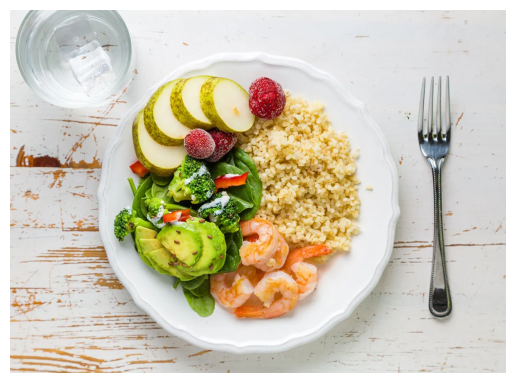

The image shows a plate of food consisting of several items: cooked shrimp, a portion of cooked bulgur or a similar grain, a fresh salad with avocado slices, broccoli, spinach or leafy greens with a light dressing, sliced pear, and a few strawberries. Next to the plate, there is a glass of water with ice and a metal fork. The setting is on a rustic white wooden surface.
Summary Length in characters:372


In [17]:
image_embedding = vision_embed(image_url)

In [16]:
def vision_rag(user_query,embedding_dict_,vision_model="gpt-4.1-mini"):

    image_url=embedding_dict_['image_url']
    response = client.responses.create(
      model=vision_model,
      input=[{

              "role":"developer",
              "content": "You are an image analysis system. You provide short answers to user queries based ONLY on the  image provided.  If the answer is not contained withing the image you respond that you don't know."
          },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": user_query},
                {
                    "type": "image_url",
                    "image_url": image_url,
                },
            ],
        },
    ],

    )
    print(response)

In [ ]:
https://www.mongodb.com/docs/charts/static/87821c53a354afffdf8f003e3f86adac/64ccf/stacked-bar-chart…

In [19]:
def vision_rag(user_query,embedding_dict_,vision_model="gpt-4.1-mini"):

    image_url=embedding_dict_['image_url']
    response = client.responses.create(
      model=vision_model,
      input=[{

              "role":"developer",#   What the AI is.
              "content": "You are an image analysis system. You provide short answers to user queries based ONLY on the  image provided.  If the answer is not contained withing the image you respond that you don't know."
          },
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": user_query},
                {
                    "type": "input_image",
                    "image_url": image_url,
                },
            ],
        },
    ],

    )
    print(response.output_text)

In [ ]:
vision_rag('What is the best thing to?',image_embedding)

The image does not specify what the best thing to eat is. It shows a plate with shrimp, avocado, spinach, broccoli, a few slices of pear, strawberries, and bulgur wheat, suggesting a healthy meal.
